# 09 Esg Eda

This notebook is designed to understand the **ESG view itself** so it can support three downstream purposes:

1. **Snorkel labeling functions**  
2. **Imputation decisions**  
3. **Feature engineering / modeling decisions**

The notebook is intentionally **not focused on joins**.  
Instead, it focuses on understanding the variables, missingness structure, distributional behavior, and whether features are suitable for:
- interpretable weak rules
- imputation
- later modeling

## Imports and project path setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from master_thesis.data_utils import load_raw, save_processed

## Load ESG data

Update the filename below if needed.

In [3]:
df_esg = load_raw("esg_yearly.csv", low_memory=False)

print("Shape:", df_esg.shape)
display(df_esg.head())

Shape: (2093, 16)


,moodys_bvd_id,company_name,risk_level,sector,year,Join_Year,esg_overall,esg_industry_adjusted,env_score,env_weight,social_score,social_weight,gov_score,gov_weight,industry_min,industry_max
0,AE0043368774,Fifth Element Event Management L.L.C,Take caution,Business Services,2023,2024,5.0,5.0,9.0,5.0,6.0,28.0,5.0,67.0,3.0,8.0
1,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2023,2024,3.0,1.0,3.0,33.0,3.0,20.0,5.0,47.0,3.0,7.0
2,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2024,2025,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
3,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2025,2026,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
4,AT9110192427,Flextronics International Gesellschaft m.b.H.,Do not source,Metals & Metal Products,2023,2024,4.0,1.0,4.0,40.0,4.0,25.0,5.0,35.0,4.0,7.0


## Standardize key column names

This makes the EDA more consistent with later feature engineering.

In [4]:
df_esg = df_esg.copy()

rename_map = {
    "Join_Year": "join_year",
    "Risk_level": "risk_level",
    "Company_name": "company_name",
    "Sector": "sector",
    "Year": "year",
    "ESG_overall": "esg_overall",
    "ESG_industry_adjusted": "esg_industry_adjusted",
    "Env_score": "env_score",
    "Env_weight": "env_weight",
    "Social_score": "social_score",
    "Social_weight": "social_weight",
    "Gov_score": "gov_score",
    "Gov_weight": "gov_weight",
    "Industry_min": "industry_min",
    "Industry_max": "industry_max",
}

rename_map = {k: v for k, v in rename_map.items() if k in df_esg.columns}
df_esg = df_esg.rename(columns=rename_map)

if "moodys_bvd_id" in df_esg.columns:
    df_esg["moodys_bvd_id"] = df_esg["moodys_bvd_id"].astype("string").str.strip()

if "join_year" in df_esg.columns:
    df_esg["join_year"] = pd.to_numeric(df_esg["join_year"], errors="coerce").astype("Int64")

if "year" in df_esg.columns:
    df_esg["year"] = pd.to_numeric(df_esg["year"], errors="coerce").astype("Int64")

print("Shape:", df_esg.shape)
print("Columns:")
print(df_esg.columns.tolist())

Shape: (2093, 16)
Columns:
['moodys_bvd_id', 'company_name', 'risk_level', 'sector', 'year', 'join_year', 'esg_overall', 'esg_industry_adjusted', 'env_score', 'env_weight', 'social_score', 'social_weight', 'gov_score', 'gov_weight', 'industry_min', 'industry_max']


## Basic structure overview

In [5]:
df_structure = pd.DataFrame({
    "feature": df_esg.columns,
    "dtype": df_esg.dtypes.astype(str).values,
    "missing_pct": df_esg.isna().mean().values * 100,
    "n_unique": df_esg.nunique(dropna=True).values,
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True]).reset_index(drop=True)

display(df_structure)
print("Total features:", len(df_structure))

,feature,dtype,missing_pct,n_unique
0,industry_min,float64,0.0,3
1,industry_max,float64,0.0,3
2,risk_level,str,0.0,4
3,year,Int64,0.0,4
4,join_year,Int64,0.0,4
5,gov_score,float64,0.0,5
6,esg_overall,float64,0.0,7
7,esg_industry_adjusted,float64,0.0,11
8,env_score,float64,0.0,11
9,social_score,float64,0.0,11


Total features: 16


## Candidate ESG columns

This separates likely numeric ESG variables from identifiers / descriptive text.

In [6]:
id_like_cols = [
    c for c in df_esg.columns
    if c in {"moodys_bvd_id", "join_year", "year", "company_name"}
    or "company_name" in c.lower()
    or "bvd" in c.lower()
]

numeric_candidate_cols = df_esg.select_dtypes(include=["number"]).columns.tolist()
numeric_candidate_cols = [c for c in numeric_candidate_cols if c not in id_like_cols]

categorical_candidate_cols = [
    c for c in df_esg.columns
    if c not in numeric_candidate_cols and c not in id_like_cols
]

print("Numeric candidate cols:", len(numeric_candidate_cols))
print("Categorical candidate cols:", len(categorical_candidate_cols))
print("ID-like cols:", id_like_cols)

Numeric candidate cols: 10
Categorical candidate cols: 2
ID-like cols: ['moodys_bvd_id', 'company_name', 'year', 'join_year']


## Missingness overview

This is critical for both imputation and deciding whether a feature is usable at all.

In [7]:
df_missing = pd.DataFrame({
    "feature": df_esg.columns,
    "missing_pct": df_esg.isna().mean().values * 100,
    "n_missing": df_esg.isna().sum().values,
    "dtype": df_esg.dtypes.astype(str).values,
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

display(df_missing)

,feature,missing_pct,n_missing,dtype
0,moodys_bvd_id,0.0,0,string
1,company_name,0.0,0,str
2,risk_level,0.0,0,str
3,sector,0.0,0,str
4,year,0.0,0,Int64
5,join_year,0.0,0,Int64
6,esg_overall,0.0,0,float64
7,esg_industry_adjusted,0.0,0,float64
8,env_score,0.0,0,float64
9,env_weight,0.0,0,float64


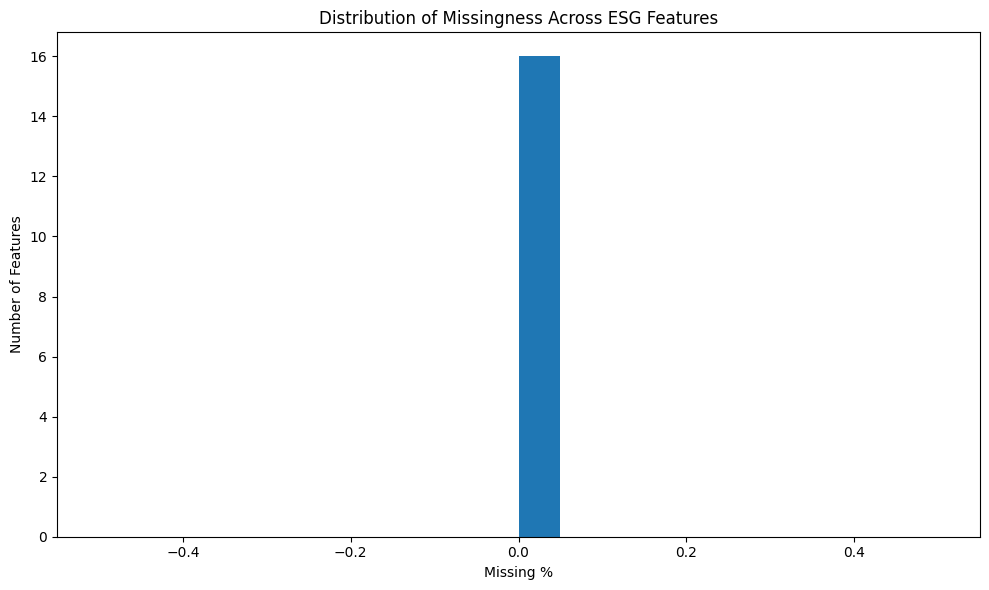

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_missing["missing_pct"], bins=20)
ax.set_title("Distribution of Missingness Across ESG Features")
ax.set_xlabel("Missing %")
ax.set_ylabel("Number of Features")
plt.tight_layout()
plt.show()

## Missingness buckets

This helps determine:
- which variables could be imputed
- which variables are too sparse
- which variables might be better summarized

In [9]:
def missing_bucket(x):
    if x == 0:
        return "0%"
    elif x <= 5:
        return "0-5%"
    elif x <= 20:
        return "5-20%"
    elif x <= 50:
        return "20-50%"
    elif x <= 80:
        return "50-80%"
    else:
        return "80%+"

df_missing["missing_bucket"] = df_missing["missing_pct"].apply(missing_bucket)

df_missing_bucket_summary = (
    df_missing.groupby("missing_bucket")
    .size()
    .reset_index(name="n_features")
)

display(df_missing_bucket_summary)

,missing_bucket,n_features
0,0%,16


## Numeric distribution screening

For numeric candidates we compute compact summary statistics.
This is useful for:
- spotting skewness / outliers
- identifying threshold candidates for Snorkel
- assessing whether median imputation is sensible

In [10]:
numeric_summary_rows = []

for col in numeric_candidate_cols:
    s = pd.to_numeric(df_esg[col], errors="coerce")
    non_missing = s.dropna()

    if len(non_missing) == 0:
        continue

    numeric_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_non_missing": non_missing.shape[0],
        "mean": non_missing.mean(),
        "median": non_missing.median(),
        "std": non_missing.std(),
        "min": non_missing.min(),
        "p01": non_missing.quantile(0.01),
        "p05": non_missing.quantile(0.05),
        "p25": non_missing.quantile(0.25),
        "p50": non_missing.quantile(0.50),
        "p75": non_missing.quantile(0.75),
        "p95": non_missing.quantile(0.95),
        "p99": non_missing.quantile(0.99),
        "max": non_missing.max(),
    })

df_numeric_summary = pd.DataFrame(numeric_summary_rows)

if not df_numeric_summary.empty:
    df_numeric_summary = df_numeric_summary.sort_values("missing_pct", ascending=False)

display(df_numeric_summary)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,esg_overall,0.0,2093,4.522695,5.0,1.018043,2.0,3.0,3.0,4.0,5.0,5.0,6.0,7.0,8.0
1,esg_industry_adjusted,0.0,2093,3.936455,4.0,2.218097,0.0,0.0,0.0,2.0,4.0,6.0,7.0,9.0,10.0
2,env_score,0.0,2093,4.775920,5.0,2.690354,0.0,0.0,0.0,3.0,5.0,7.0,9.0,10.0,10.0
3,env_weight,0.0,2093,17.267081,15.0,14.327995,5.0,5.0,5.0,5.0,15.0,23.0,55.0,56.0,62.0
4,social_score,0.0,2093,3.812231,4.0,2.223549,0.0,0.0,0.0,2.0,4.0,5.0,8.0,9.0,10.0
5,social_weight,0.0,2093,37.242714,35.0,14.091627,5.0,11.0,12.0,25.0,35.0,51.0,58.0,60.0,62.0
6,gov_score,0.0,2093,5.454849,5.0,0.659894,3.0,4.0,4.0,5.0,5.0,6.0,6.0,7.0,7.0
7,gov_weight,0.0,2093,45.490205,44.0,10.598600,33.0,33.0,33.0,35.0,44.0,54.0,67.0,67.0,67.0
8,industry_min,0.0,2093,2.722886,3.0,0.540551,2.0,2.0,2.0,2.0,3.0,3.0,3.0,4.0,4.0
9,industry_max,0.0,2093,6.974200,7.0,0.597400,6.0,6.0,6.0,7.0,7.0,7.0,8.0,8.0,8.0


## Categorical screening

This is important for possible interpretable Snorkel rules and later feature engineering.

In [11]:
print("Categorical candidate columns:")
print(categorical_candidate_cols)
print("Number of categorical candidate columns:", len(categorical_candidate_cols))

Categorical candidate columns:
['risk_level', 'sector']
Number of categorical candidate columns: 2


In [12]:
categorical_summary_rows = []

for col in categorical_candidate_cols:
    s = df_esg[col].astype("string")
    top_values = s.value_counts(dropna=False).head(5)

    categorical_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_unique": s.nunique(dropna=True),
        "top_1": str(top_values.index[0]) if len(top_values) > 0 else None,
        "top_1_count": int(top_values.iloc[0]) if len(top_values) > 0 else None,
        "top_2": str(top_values.index[1]) if len(top_values) > 1 else None,
        "top_2_count": int(top_values.iloc[1]) if len(top_values) > 1 else None,
    })

if len(categorical_summary_rows) == 0:
    df_categorical_summary = pd.DataFrame(
        columns=[
            "feature",
            "missing_pct",
            "n_unique",
            "top_1",
            "top_1_count",
            "top_2",
            "top_2_count",
        ]
    )
else:
    df_categorical_summary = pd.DataFrame(categorical_summary_rows).sort_values(
        "missing_pct",
        ascending=False
    )

display(df_categorical_summary)

,feature,missing_pct,n_unique,top_1,top_1_count,top_2,top_2_count
0,risk_level,0.0,4,Take caution,1061,Go ahead,722
1,sector,0.0,28,Business Services,629,Wholesale,274


## Snorkel-oriented EDA

The purpose here is to identify variables that can support simple, interpretable rules.
Typical good candidates are:
- low overall ESG score
- low industry-adjusted score
- weak environmental / social / governance scores
- explicit ESG risk categories if available

In [13]:
snorkel_candidate_cols = [
    c for c in [
        "risk_level",
        "esg_overall",
        "esg_industry_adjusted",
        "env_score",
        "social_score",
        "gov_score",
        "industry_min",
        "industry_max",
    ]
    if c in df_esg.columns
]

print("Snorkel candidate columns:")
print(snorkel_candidate_cols)

Snorkel candidate columns:
['risk_level', 'esg_overall', 'esg_industry_adjusted', 'env_score', 'social_score', 'gov_score', 'industry_min', 'industry_max']


In [14]:
for col in [c for c in ["risk_level", "sector"] if c in df_esg.columns]:
    print(f"\n=== {col} ===")
    display(df_esg[col].astype("string").value_counts(dropna=False).to_frame("count"))


=== risk_level ===


,count
risk_level,
Take caution,1061
Go ahead,722
Do not source,309
No data,1



=== sector ===


,count
sector,
Business Services,629
Wholesale,274
"Chemicals, Petroleum, Rubber & Plastic",266
Construction,180
"Industrial, Electric & Electronic Machinery",137
Computer Software,101
Biotechnology and Life Sciences,70
"Wood, Furniture & Paper Manufacturing",60
"Travel, Personal & Leisure",54


In [15]:
if not df_numeric_summary.empty:
    df_snorkel_thresholds = df_numeric_summary[
        df_numeric_summary["feature"].isin(
            [c for c in snorkel_candidate_cols if c in df_numeric_summary["feature"].values]
        )
    ].copy()
else:
    df_snorkel_thresholds = pd.DataFrame()

display(df_snorkel_thresholds)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,esg_overall,0.0,2093,4.522695,5.0,1.018043,2.0,3.0,3.0,4.0,5.0,5.0,6.0,7.0,8.0
1,esg_industry_adjusted,0.0,2093,3.936455,4.0,2.218097,0.0,0.0,0.0,2.0,4.0,6.0,7.0,9.0,10.0
2,env_score,0.0,2093,4.775920,5.0,2.690354,0.0,0.0,0.0,3.0,5.0,7.0,9.0,10.0,10.0
4,social_score,0.0,2093,3.812231,4.0,2.223549,0.0,0.0,0.0,2.0,4.0,5.0,8.0,9.0,10.0
6,gov_score,0.0,2093,5.454849,5.0,0.659894,3.0,4.0,4.0,5.0,5.0,6.0,6.0,7.0,7.0
8,industry_min,0.0,2093,2.722886,3.0,0.540551,2.0,2.0,2.0,2.0,3.0,3.0,3.0,4.0,4.0
9,industry_max,0.0,2093,6.974200,7.0,0.597400,6.0,6.0,6.0,7.0,7.0,7.0,8.0,8.0,8.0


## Useful sanity relationships inside the ESG view

These checks help understand whether the ESG fields behave as expected.

In [16]:
esg_score_cols = [c for c in ["esg_overall", "esg_industry_adjusted", "env_score", "social_score", "gov_score"] if c in df_esg.columns]

if esg_score_cols:
    display(df_esg[esg_score_cols].describe(include="all").T)

,count,mean,std,min,25%,50%,75%,max
esg_overall,2093.0,4.522695,1.018043,2.0,4.0,5.0,5.0,8.0
esg_industry_adjusted,2093.0,3.936455,2.218097,0.0,2.0,4.0,6.0,10.0
env_score,2093.0,4.775920,2.690354,0.0,3.0,5.0,7.0,10.0
social_score,2093.0,3.812231,2.223549,0.0,2.0,4.0,5.0,10.0
gov_score,2093.0,5.454849,0.659894,3.0,5.0,5.0,6.0,7.0


In [17]:
if {"industry_min", "industry_max", "esg_industry_adjusted"}.issubset(df_esg.columns):
    df_esg["industry_range_valid"] = (
        (pd.to_numeric(df_esg["esg_industry_adjusted"], errors="coerce") >= pd.to_numeric(df_esg["industry_min"], errors="coerce")) &
        (pd.to_numeric(df_esg["esg_industry_adjusted"], errors="coerce") <= pd.to_numeric(df_esg["industry_max"], errors="coerce"))
    )

    print("Rows where industry-adjusted ESG falls inside min-max range:",
          df_esg["industry_range_valid"].sum(),
          "out of",
          df_esg["industry_range_valid"].notna().sum())

Rows where industry-adjusted ESG falls inside min-max range: 1504 out of 2093


## Imputation-oriented EDA

This section is not about fitting imputation yet.
It is about deciding whether imputation is even reasonable.

In [18]:
df_imputation_candidates = df_structure.copy()

def imputation_recommendation(row):
    missing_pct = row["missing_pct"]
    dtype = row["dtype"]

    if missing_pct == 0:
        return "no imputation needed"
    if missing_pct > 85:
        return "too sparse; prefer missing flag / view indicator / summary"
    if "float" in dtype or "int" in dtype:
        if missing_pct <= 50:
            return "median impute + missing flag"
        return "consider summary feature + missing flag"
    if "object" in dtype or "string" in dtype:
        return "missing category / explicit unknown"
    return "inspect manually"

df_imputation_candidates["imputation_recommendation"] = df_imputation_candidates.apply(
    imputation_recommendation,
    axis=1,
)

display(df_imputation_candidates.sort_values("missing_pct", ascending=False))

,feature,dtype,missing_pct,n_unique,imputation_recommendation
0,industry_min,float64,0.0,3,no imputation needed
1,industry_max,float64,0.0,3,no imputation needed
2,risk_level,str,0.0,4,no imputation needed
3,year,Int64,0.0,4,no imputation needed
4,join_year,Int64,0.0,4,no imputation needed
5,gov_score,float64,0.0,5,no imputation needed
6,esg_overall,float64,0.0,7,no imputation needed
7,esg_industry_adjusted,float64,0.0,11,no imputation needed
8,env_score,float64,0.0,11,no imputation needed
9,social_score,float64,0.0,11,no imputation needed


## Feature-engineering-oriented EDA

This section identifies raw ESG columns that may be better converted into more robust engineered signals.

In [19]:
feature_engineering_candidate_cols = [
    c for c in [
        "esg_overall",
        "esg_industry_adjusted",
        "env_score",
        "env_weight",
        "social_score",
        "social_weight",
        "gov_score",
        "gov_weight",
        "industry_min",
        "industry_max",
    ]
    if c in df_esg.columns
]

print(feature_engineering_candidate_cols)

['esg_overall', 'esg_industry_adjusted', 'env_score', 'env_weight', 'social_score', 'social_weight', 'gov_score', 'gov_weight', 'industry_min', 'industry_max']


In [20]:
df_corr_input = df_esg[feature_engineering_candidate_cols].copy()

for col in df_corr_input.columns:
    df_corr_input[col] = pd.to_numeric(df_corr_input[col], errors="coerce")

df_corr = df_corr_input.corr(numeric_only=True)

display(df_corr)

,esg_overall,esg_industry_adjusted,env_score,env_weight,social_score,social_weight,gov_score,gov_weight,industry_min,industry_max
esg_overall,1.000000,0.862094,0.401612,-0.165073,0.755221,-0.128368,0.304819,0.393833,0.048785,0.345219
esg_industry_adjusted,0.862094,1.000000,0.242648,-0.150792,0.741339,-0.031469,0.280690,0.245692,-0.255096,0.110591
env_score,0.401612,0.242648,1.000000,-0.384280,0.014858,0.163292,0.078170,0.302389,0.262966,0.264967
env_weight,-0.165073,-0.150792,-0.384280,1.000000,-0.116401,-0.721962,0.003374,-0.391974,-0.019941,-0.053867
social_score,0.755221,0.741339,0.014858,-0.116401,1.000000,-0.055174,0.073871,0.230718,-0.075923,0.172320
social_weight,-0.128368,-0.031469,0.163292,-0.721962,-0.055174,1.000000,-0.010336,-0.353571,-0.138324,-0.295091
gov_score,0.304819,0.280690,0.078170,0.003374,0.073871,-0.010336,1.000000,0.009181,0.011810,0.097685
gov_weight,0.393833,0.245692,0.302389,-0.391974,0.230718,-0.353571,0.009181,1.000000,0.210869,0.465167
industry_min,0.048785,-0.255096,0.262966,-0.019941,-0.075923,-0.138324,0.011810,0.210869,1.000000,0.192486
industry_max,0.345219,0.110591,0.264967,-0.053867,0.172320,-0.295091,0.097685,0.465167,0.192486,1.000000


In [21]:
high_corr_pairs = []

if not df_corr.empty:
    corr_matrix = df_corr.abs()
    for i, col1 in enumerate(corr_matrix.columns):
        for col2 in corr_matrix.columns[i+1:]:
            corr_val = corr_matrix.loc[col1, col2]
            if pd.notna(corr_val) and corr_val >= 0.80:
                high_corr_pairs.append({
                    "feature_1": col1,
                    "feature_2": col2,
                    "abs_corr": corr_val,
                })

df_high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])
display(df_high_corr_pairs)

,feature_1,feature_2,abs_corr
0,esg_overall,esg_industry_adjusted,0.862094


## Final decision table

This is the most important output of the notebook.

Each feature gets an initial recommendation for:
- Snorkel suitability
- imputation strategy
- feature engineering action

In [22]:
df_feature_decisions = df_structure.copy()

snorkel_candidate_set = set(snorkel_candidate_cols)

def snorkel_flag(feature):
    return "yes" if feature in snorkel_candidate_set else "no"

def feature_engineering_decision(row):
    feature = row["feature"]
    missing_pct = row["missing_pct"]

    if feature in snorkel_candidate_set and missing_pct <= 85:
        return "engineer interpretable flags / thresholds / summaries"
    if missing_pct > 85:
        return "drop raw / summarize if important"
    if missing_pct > 50:
        return "keep only if strong business relevance"
    return "keep or engineer"

df_feature_decisions["snorkel_candidate"] = df_feature_decisions["feature"].apply(snorkel_flag)
df_feature_decisions = df_feature_decisions.merge(
    df_imputation_candidates[["feature", "imputation_recommendation"]],
    on="feature",
    how="left",
)
df_feature_decisions["feature_engineering_decision"] = df_feature_decisions.apply(
    feature_engineering_decision,
    axis=1,
)

display(df_feature_decisions.sort_values(["snorkel_candidate", "missing_pct"], ascending=[False, False]))

,feature,dtype,missing_pct,n_unique,snorkel_candidate,imputation_recommendation,feature_engineering_decision
0,industry_min,float64,0.0,3,yes,no imputation needed,engineer interpretable flags / thresholds / su...
1,industry_max,float64,0.0,3,yes,no imputation needed,engineer interpretable flags / thresholds / su...
2,risk_level,str,0.0,4,yes,no imputation needed,engineer interpretable flags / thresholds / su...
5,gov_score,float64,0.0,5,yes,no imputation needed,engineer interpretable flags / thresholds / su...
6,esg_overall,float64,0.0,7,yes,no imputation needed,engineer interpretable flags / thresholds / su...
7,esg_industry_adjusted,float64,0.0,11,yes,no imputation needed,engineer interpretable flags / thresholds / su...
8,env_score,float64,0.0,11,yes,no imputation needed,engineer interpretable flags / thresholds / su...
9,social_score,float64,0.0,11,yes,no imputation needed,engineer interpretable flags / thresholds / su...
3,year,Int64,0.0,4,no,no imputation needed,keep or engineer
4,join_year,Int64,0.0,4,no,no imputation needed,keep or engineer


## Save EDA outputs

These outputs can be reused later in:
- Snorkel notebook
- feature engineering notebook
- modeling discussion

In [23]:
save_processed(df_structure, "esg_eda_structure.csv")
save_processed(df_missing, "esg_eda_missingness.csv")
save_processed(df_numeric_summary, "esg_eda_numeric_summary.csv")
save_processed(df_categorical_summary, "esg_eda_categorical_summary.csv")
save_processed(df_imputation_candidates, "esg_eda_imputation_candidates.csv")
save_processed(df_feature_decisions, "esg_eda_feature_decisions.csv")
save_processed(df_high_corr_pairs, "esg_eda_high_corr_pairs.csv")

print("Saved ESG EDA outputs to Data/processed/")

Saved ESG EDA outputs to Data/processed/


## Short interpretation notes

Use this section to summarize:
- which ESG variables are strong LF candidates
- which variables are too sparse for direct use
- where missingness itself is informative
- which raw variables should later be converted into engineered ESG risk / stress signals